In [86]:
# import all packages
import pandas as pd
import numpy as np
import random as rd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [87]:
# generate temporary data
streets = ['street' + str(i) for i in range (1,101)]
wa = ['wa' + str(i) for i in range(1,6)]
uw = ['uw' + str(i) for i in range(1,6)]

df = pd.DataFrame(columns=[*wa, *uw], index=streets)

for street in df.index:
    df.loc[street,'wa1':'wa5'] = np.random.poisson(lam=rd.randrange(10,1000), size=5)
    df.loc[street,'uw1':'uw5'] = np.random.poisson(lam=rd.randrange(10,1000), size=5)

df

,wa1,wa2,wa3,wa4,wa5,uw1,uw2,uw3,uw4,uw5
street1,62,58,67,59,60,619,681,642,639,673
street2,189,171,164,156,168,336,339,360,367,366
street3,34,25,33,40,22,346,326,342,325,302
street4,327,313,326,289,316,457,412,489,504,420
street5,122,110,128,128,124,339,310,321,339,356
...,...,...,...,...,...,...,...,...,...,...
street96,803,793,825,756,802,128,113,118,94,119
street97,344,333,326,339,324,157,155,149,181,147
street98,887,851,847,856,864,856,869,897,864,864
street99,794,793,810,815,796,854,842,799,850,875


In [88]:
# scale data
scaled_data = StandardScaler().fit_transform(df.T)

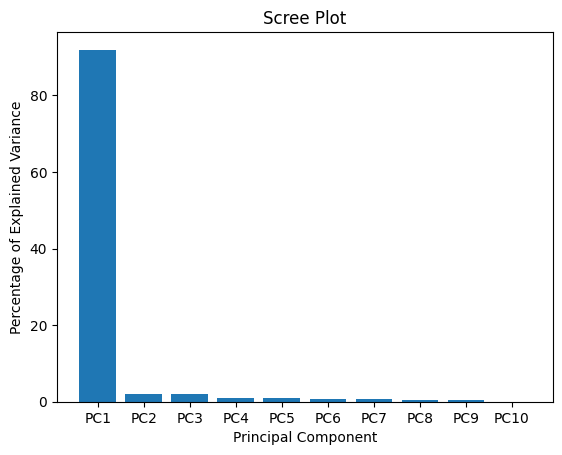

In [89]:
# run PCA calculations
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

# generate scree plot to visualize variation captured per PC
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range (1, len(per_var) + 1)]

plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

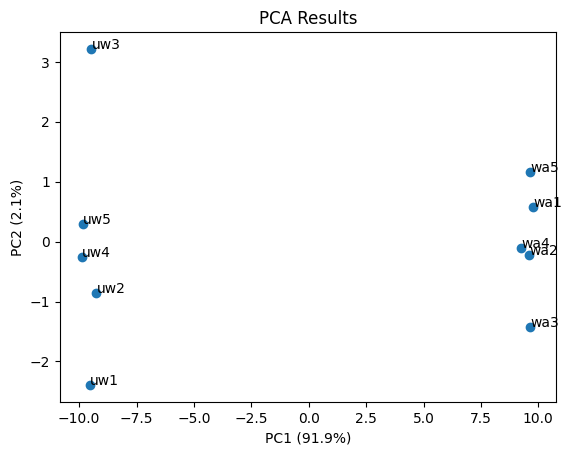

In [ ]:
# show PCA data
pca_df = pd.DataFrame(pca_data, index=[*wa, *uw], columns=labels)
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title('PCA Results')
plt.xlabel('PC1 ({0}%)'.format(per_var[0]))
plt.ylabel('PC2 ({0}%)'.format(per_var[1]))

for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))

plt.show()